<a href="https://colab.research.google.com/github/brandon5254/Data_Science/blob/main/BrandonTobar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Brandon Eduardo Tobar Sanchez
- Correo: betobars@correo.usbcali.edu.co


# Cargar librerias

In [ ]:
# ejemplos
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt



# Cargar conjunto de datos

se puede cargarde desde cualquier fuente estrcturada (csv, sql, xml ... etc)


In [ ]:
import kagglehub
import pandas as pd

# Descargar el dataset
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

# Mostrar la ruta del dataset
print("Path to dataset files:", path)

# Cargar el archivo en un DataFrame
df = pd.read_csv(f"{path}/diabetes.csv")  # Asegúrate de que el nombre del archivo es correcto

# Mostrar las primeras filas
df.head()


Path to dataset files: /root/.cache/kagglehub/datasets/uciml/pima-indians-diabetes-database/versions/1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Analizar y visualizar el conjunto de datos


- Estadisticas (df.info(), df.describe())
- Histogramas (distribución normal)

In [ ]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Estadísticas descriptivas
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


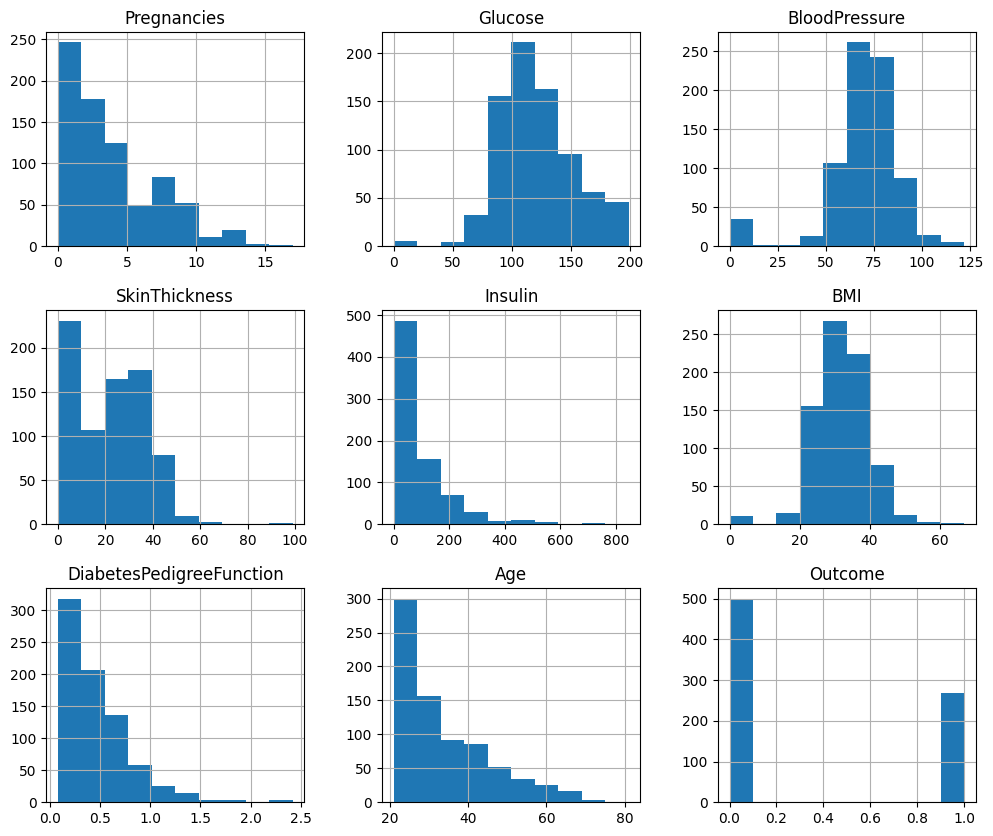

In [ ]:
# Visualizar la distribución de las variables numéricas con histogramas
df.hist(figsize=(12, 10))
plt.show()

# Limpiar el conjunto de datos

- Valores perdidos-nulos-anomalias
- Limpieza de datos
- Normalizar

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Revisar si hay valores nulos
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Definir las variables independientes (X) y la variable objetivo (y)
X = df.drop(columns=["Outcome"])  # Todas las columnas excepto la variable objetivo
y = df["Outcome"]  # La variable objetivo (0 = No Diabetes, 1 = Diabetes)

In [ ]:
# Revisar si hay valores nulos
print("Valores nulos por columna:\n", X.isnull().sum())

Valores nulos por columna:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [ ]:
# Reemplazar valores 0 en columnas donde no deberían existir
cols_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_to_fix:
    X[col].replace(0, np.nan, inplace=True)  # Reemplazar 0 por NaN
    X[col].fillna(X[col].median(), inplace=True)  # Rellenar con la mediana

<ipython-input-11-f7b84cf4d5f6>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].replace(0, np.nan, inplace=True)  # Reemplazar 0 por NaN
<ipython-input-11-f7b84cf4d5f6>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [ ]:
# Reemplazar valores 0 en columnas donde no deberían existir
cols_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_to_fix:
    X[col].replace(0, np.nan, inplace=True)  # Reemplazar 0 por NaN
    X[col].fillna(X[col].median(), inplace=True)  # Rellenar con la mediana

# Revisar si quedan valores nulos después de la imputación
print("Valores nulos por columna después de la imputación:\n", X.isnull().sum())

Valores nulos por columna después de la imputación:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


<ipython-input-12-e2eec88083fd>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].replace(0, np.nan, inplace=True)  # Reemplazar 0 por NaN
<ipython-input-12-e2eec88083fd>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [ ]:
# Verificar que ya no haya valores nulos
print(X.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [ ]:
# Reemplazar valores NaN en variables numéricas con la mediana de cada columna
df.fillna(df.median(numeric_only=True), inplace=True)

# Verificar si aún hay NaN
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:

# Seleccionar columnas numéricas a normalizar (todas menos 'Outcome')
num_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Inicializar el MinMaxScaler
scaler = MinMaxScaler()

# Aplicar normalización
df[num_cols] = scaler.fit_transform(df[num_cols])

# Verificar el resultado
df[num_cols].describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.226180,0.607510,0.566438,0.207439,0.094326,0.476790,0.168179,0.204015
std,0.198210,0.160666,0.158654,0.161134,0.136222,0.117499,0.141473,0.196004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058824,0.497487,0.508197,0.000000,0.000000,0.406855,0.070773,0.050000
50%,0.176471,0.587940,0.590164,0.232323,0.036052,0.476900,0.125747,0.133333
75%,0.352941,0.704774,0.655738,0.323232,0.150414,0.545455,0.234095,0.333333
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#Modelo de machine learning para clasificación





# Dividir el df en variables independientes y dependiente

In [ ]:
# Definir las variables independientes (X) y la variable objetivo (y)
X = df.drop(columns=['Outcome'])  # Eliminamos la variable objetivo de las features
y = df['Outcome']  # Variable objetivo (0 = No Diabetes, 1 = Diabetes)

# Verificar las primeras filas de X e y
print(X.head())
print(y.head())


# Particionar el conjuton de datos en datos de pueba y entrenamiento



In [ ]:
# Dividir el dataset en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Verificamos la cantidad de datos en cada conjunto
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

#Implementar el modelo de ML

In [ ]:
print("Primeras filas de X:")
print(X.head())

print("\nPrimeras filas de y:")
print(y.head())

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)


In [ ]:


# Definir el modelo con hiperparámetros iniciales
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Entrenar el modelo con  los datos de entrenamiento
modelo_rf.fit(X_train, y_train)

#  Predecir con los datos de prueba
y_pred = modelo_rf.predict(X_test)

print("Modelo entrenado y predicciones hecha con exito.")



In [ ]:


# Evaluar el modelo
print(" Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Calcular y mostrar la precisión (accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Accuracy del modelo: {accuracy:.4f}")


In [ ]:


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Probar diferentes valores de k
best_k = 1
best_score = 0

for k in range(1, 21):  # Probamos de 1 a 20 vecinos
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"k={k}, Accuracy={acc:.4f}")

    if acc > best_score:
        best_score = acc
        best_k = k

print(f"\n Mejor k encontrado: {best_k} con Accuracy={best_score:.4f}")


In [ ]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE solo a los datos de entrenamiento
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Entrenar un nuevo modelo con los datos balanceados
modelo_rf_smote = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
modelo_rf_smote.fit(X_train_smote, y_train_smote)

# Hacer predicciones
y_pred_smote = modelo_rf_smote.predict(X_test)

# Evaluar el modelo
print(classification_report(y_test, y_pred_smote))

#Implementar las metricas diagnosticas para evaluar el rendimiento del modelo de ML

In [ ]:
print(classification_report(y_test, y_pred))

#Implementar las metricas diagnosticas de visualización

- Matriz de confusión
- Curva ROC

In [ ]:

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print(cm)

# Create a heatmap of the confusion matrix
import matplotlib.pyplot as plt

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))

# Fill in the values of the confusion matrix
for i in range(len(np.unique(y_test))):
  for j in range(len(np.unique(y_test))):
    plt.text(j, i, str(cm[i][j]), ha='center', va='center', color='white')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


In [ ]:


# Obtener probabilidades de predicción para la clase positiva (1)
y_probs = modelo_rf.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')  # Línea diagonal de referencia

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend(loc="lower right")
plt.show()


# Discusión de los resultados
- Que tan bueno o malo fue el modelo para cada clase

Finalmente, podemos concluir que en este análisis, el modelo de clasificación basado en Random Forest fue entrenado para predecir si un paciente tiene diabetes o no, basándose en distintas variables clínicas. En términos generales, su precisión es del 76%, lo que significa que acierta en aproximadamente 3 de cada 4 casos.

Si miramos los resultados por clase, el modelo funciona bastante bien para identificar a los pacientes sin diabetes (Clase 0). Tiene una precisión del 78% y un recall del 88%, lo que indica que la mayoría de los casos negativos son clasificados correctamente. En la matriz de confusión, esto se traduce en 136 aciertos y solo 14 falsos positivos, es decir, pocos pacientes sanos fueron clasificados erróneamente como diabéticos.

Sin embargo, el desempeño disminuye cuando se trata de identificar a los pacientes con diabetes (Clase 1). Aquí, la precisión es del 71%, pero el recall solo alcanza el 54%, lo que significa que casi la mitad de los pacientes con diabetes fueron clasificados como sanos. Esto se ve reflejado en los 47 falsos negativos de la matriz de confusión, un aspecto preocupante, ya que implica que muchas personas con diabetes pasarían desapercibidas para el modelo. En resumen, el modelo es confiable para predecir quién no tiene diabetes, pero aún le cuesta identificar correctamente a quienes sí la tienen, algo que sin duda se debería mejorar.

Si observamos la curva ROC, el modelo tiene un AUC de 0.72, lo que indica que su capacidad para diferenciar entre pacientes con y sin diabetes es moderada. En otras palabras, hace un buen trabajo identificando a quienes no tienen la enfermedad, pero sigue teniendo dificultades para detectar correctamente a los pacientes diabéticos.

Para mejorar estos resultados, se pueden probar varias estrategias. Por ejemplo, ajustar el umbral de decisión ayudaría a reducir la cantidad de falsos negativos y permitiría que el modelo identifique mejor los casos positivos. También sería útil aplicar técnicas de equilibrio de clases, como SMOTE o submuestreo, para evitar que el modelo aprenda de manera sesgada y mejorar su capacidad de detección en pacientes diabéticos. Además, la optimización de hiperparámetros podría afinar aún más su rendimiento y hacerlo más preciso.